We aim to optimize the function g(x,y) = (1 - x)^2 + 100(y - x^2)^2 + 2*sin(3x),
under domain -3 ≤ x,y ≤ 3.
Each candidate solution is represented as a vector (x,y).

a) Describe what kinds of optimization problems GAs are particularly suited for. Is
the problem above suitable for a GA, if so why? (1p)

- finding best solution of an equation with two unkowns 
- can get local minima 
- continuous genetic algorithims better?
- real values used instead of binary
- can explore huge combinatorial spaces
- avoids getting stuck in bad local optima
- faster

b) Explain how selection, recombination, mutation, and replacement relate to
biological evolution and GA alike. (1p)

Selection: individuals with a higher fitness are more likely to reproduce and pass on their genes. This is true in a GA, as a GA will sort the population by fitness and will pair parents in descending fitness order. A GA will often also have a cutoff in which only the top x% of individuals can reproduce. Higher fitness alleles will be selected for while lower fitness alleles will be selected against. 

Recombination: in reproduction events, crossover events can occur in which a new combination of genes (some from parent 1 and some from parent 2) create a new chromosome in the population. This allows for further genetic variation and an opportunity to increase fitness. This is modeled in a GA with a single crossover, in which a combination point is determined at random. This provides another opportunity for a GA to find a global optimum. 

Mutation: in biological evoluion, mutation is important in increasing genetic diversity in a population. A mutation can either decrease, increase, or keep fitness the same. This is modeled in GA as a mutation rate can be introduced to manipulate offspring. This adds a random element and an opportunity for higher fitness alleles to appear and global optima to be found. 

Replacement: replacement denotes an entirely new generation. It mirrors biological evolution, as presumably the newer generation has an entirely new order of fitness and new alleles (due to mutation and crossover events).

c) Write an R function that takes two parent chromosomes and returns an offspring
using one‑point crossover. (1p)

In [ ]:

gene_number <- 8         # gene number is number of genes in each chromosome (must be predefined here for my code to work)

# function to create two random parental chromosomes to then use in the function for Question1c
Create_parents <- function(gene_number) {    # This function creates a random set of two parent chromosomes and takes in gene_number as input
  ch1 <- c()
  ch2 <- c()
  
  for(gene_index in 1:gene_number) {      # For each gene in the chromosome 
    if(runif(1) < 0.5) {                   # fill genes with either 0 or 1
      ch1[gene_index] <- 0            # 50% prob of adding 0 or 1
    } else {                        
      ch1[gene_index] <- 1           # append to parent 1 chromosome by gene_index until filled
    }
  }

  for(gene_index in 1:gene_number) {      # restart the for loop to fill parent 2 chromosome in the same way as above
      if(runif(1) < 0.5) {                  
        ch2[gene_index] <- 0           
      } else {                        
        ch2[gene_index] <- 1           
      }
  
    }

  return(list(ch1 = ch1, ch2 = ch2))  # return a list with parent 1 and parent 2 chromosomes
}

# actual function for question1c
offspring <- function(parents_list) {   # function takes in the parents_list generated by the function above
  offspring <- c()  # opens and empty vector for the one offspring produced
  crossover <- sample.int(gene_number, 1) # choose a random crossover point along the chr (in our ex case among 8 genes)
  for(gene_index in 1:gene_number) {   # loop through the gene_index in the total genes
    if(gene_index <= crossover) {     # if the index is less than or equal to the crossover point --> append genes from parent 1 until the index in the offspring vec
      offspring[gene_index] <- parents_list$ch1[gene_index]
    } else {   # if the index is greater than the crossover point, do the same for the rest of the gene_indexes but from parent 2
      offspring[gene_index] <- parents_list$ch2[gene_index]
    }
  }
  return(offspring)  # return the one offspring produced after reproduction and one crossover event
}
  

# to show functionality 
parents_list <- Create_parents(gene_number)  # create two random parental chromosomes

print(parents_list)

offspring <- offspring(parents_list)  # perform one reproduction event with one point of crossover

print(offspring)

  

$ch1
[1] 1 0 0 1 1 0 1 0

$ch2
[1] 0 0 1 1 1 0 0 1

[1] 1 0 0 1 1 0 0 1


d) Modify your function in (c) to include mutation with probability 0.1 and truncated
to the valid range. (1p)

In [1]:

gene_number <- 8         # gene number is number of genes in each chromosome (must be predefined here for my code to work)
mutation_rate <- 0.1     # defining the mutation rate

# function to create two random parental chromosomes to then use in the function for Question1c
Create_parents <- function(gene_number) {    # This function creates a random set of two parent chromosomes and takes in gene_number as input
  ch1 <- c()
  ch2 <- c()
  
  for(gene_index in 1:gene_number) {      # For each gene in the chromosome 
    if(runif(1) < 0.5) {                   # fill genes with either 0 or 1
      ch1[gene_index] <- 0            # 50% prob of adding 0 or 1
    } else {                        
      ch1[gene_index] <- 1           # append to parent 1 chromosome by gene_index until filled
    }
  }

  for(gene_index in 1:gene_number) {      # restart the for loop to fill parent 2 chromosome in the same way as above
      if(runif(1) < 0.5) {                  
        ch2[gene_index] <- 0           
      } else {                        
        ch2[gene_index] <- 1           
      }
  
    }

  return(list(ch1 = ch1, ch2 = ch2))  # return a list with parent 1 and parent 2 chromosomes
}

# actual function for question1c with modified mutation rate added
offspring <- function(parents_list, mutation_rate) {   # function takes in the parents_list generated by the function above
  offspring <- c()  # opens and empty vector for the one offspring produced
  crossover <- sample.int(gene_number, 1) # choose a random crossover point along the chr (in our ex case among 8 genes)
  for(gene_index in 1:gene_number) {   # loop through the gene_index in the total genes
    if(gene_index <= crossover) {     # if the index is less than or equal to the crossover point --> append genes from parent 1 until the index in the offspring vec
      offspring[gene_index] <- parents_list$ch1[gene_index]
    } else {   # if the index is greater than the crossover point, do the same for the rest of the gene_indexes but from parent 2
      offspring[gene_index] <- parents_list$ch2[gene_index]
    }
  }

  for(gene_index in 1:gene_number) {     # mutation handled after cross-over event, looping again through gene index within gene_number
    if(runif(1) <= mutation_rate) {    # generate a random number between 0-1, if the number is less than or euqal to the mutation rate
      if(offspring[gene_index] == 0) {  #  mutate (so flip from 0 to 1 or 1 to 0 to model a mutation)
        offspring[gene_index] <- 1
      } else {
        offspring[gene_index] <- 0
      }
    }     # if mutation rate is not satisfied then the function will keep the offspring bit the same
  }

  return(offspring)  # return the one offspring produced after reproduction and one crossover event
}
  

# to show functionality 
parents_list <- Create_parents(gene_number)  # create two random parental chromosomes

print(parents_list)

offspring <- offspring(parents_list, mutation_rate)  # perform one reproduction event with one point of crossover

print(offspring)

  

$ch1
[1] 1 0 1 1 1 0 0 1

$ch2
[1] 0 1 1 1 1 0 1 1

[1] 0 0 1 1 1 0 0 1


e) Write a full GA simulation in R using population size n=50, for at least 50
generations, with ranking selection, recombination, mutation, and a plot of mean and
best fitness over time. (2p)

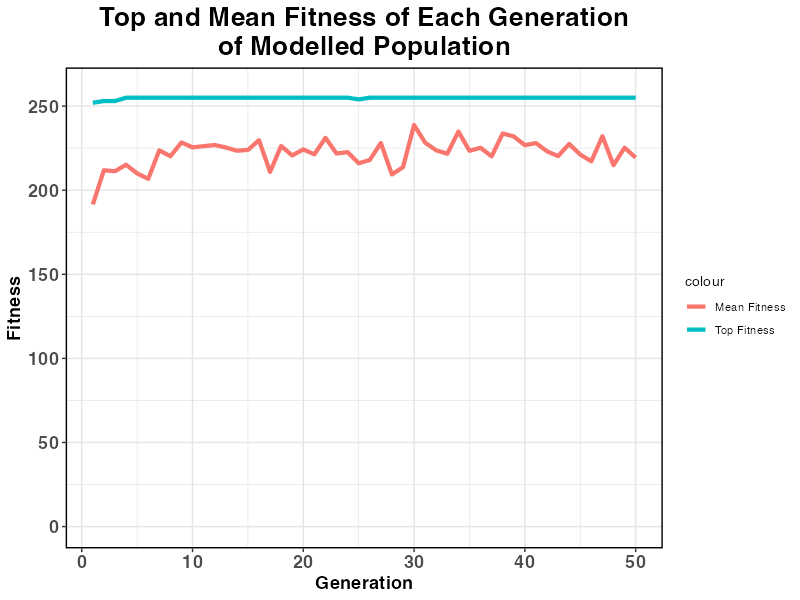

In [34]:
#install.packages("ggplot2")
#library(ggplot2)

##########################################################################################

gene_number <- 8         # gene number is number of genes in each chromosome (must be predefined here for my code to work)
pop_size <- 50           # setting pop size
max_generation <- 50     # setting maximum generations
num_breed <- 30          # setting up ranking selection parameter (only 30 best are allowed to breed)


mutation_rate <- 0.1     # defining the mutation rate, not including any to be saved from mutation 

##########################################################################################

# instead of just generating two random parents --> generate a random population 
Create_pop <- function(pop_size,gene_number) {    # This function creates a random set of two parent chromosomes and takes in gene_number as input

  genes <- matrix(nrow=pop_size, ncol=gene_number)
  
  for(ind in 1:pop_size) {              # For each individual:
    for(gene_index in 1:gene_number) {      # For each gene in the chromosome
      if(runif(1) < 0.5) {                   # fill genes with either 0 or 1 (binary bits)
        genes[ind,gene_index] <- 0            # 50% prob of added 0 or 1
      } else {                        
        genes[ind,gene_index] <- 1           
      }
    }
  }


  fitness <- rep(NA,pop_size)    # creates a fitness vec with NA with length of pop_size (so in our case 50) (will be used in ranking selection)
  # return a list with necessary variables for our GA 
  pop <- list(size=pop_size, gene_number=gene_number, genes=genes, fitness=fitness)
  return(pop) 
}

##########################################################################################

# Function to calculate fitness for each individual: converting from base 2 (0 1 1 0) to base 10 (decimal) (for ranking selection)
Evaluate_fitness <- function(pop) {
  for(ind in 1:pop$size) {                     # for each index in pop size (1, 2, 3,...50)
    # Calculate the binary number corresponding to the chromosome of ones and zeros:
    Binary_Value <- 0;                         # initate an empty binary value
    for(gene_index in gene_number:1) {         # loop over each gene for the chromosome but start with the last gene (right most bit is least significant)
      if(pop$genes[ind,gene_index] == 1) {     #if the gene is 1 add the power of 2 (in binary, each position represents a power of 2 )
        Binary_Value <- Binary_Value + 2^(gene_number - gene_index) # this will be the current binary value + the gene_number (should be the same for all) minus the index of the gene starting from the righthand side
      }
    }
    pop$fitness[ind] <- Binary_Value            # store the decimal value for this individual (all this is doing is filling the fitness parameter of pop)
  }
  return(pop)
}

##########################################################################################

# Sort the population by fitness for ranked selection:
Sort <- function(pop) {
  # Find order of decreasing fitness:
  new_order <- order(pop$fitness, decreasing=TRUE) #order by the fitness in decreasing order
  # Next, rearrange the population gene matrix and fitness vector:
  pop$genes <- pop$genes[new_order,]
  pop$fitness <- pop$fitness[new_order]
  return(pop)
}

# best individual is first 

##########################################################################################

# reproduction of entire population --> only allowing top fitness to reproduce
Reproduce <- function(pop,num_breeed) {
  # The population reproduces in pairs, in fitness order
  # First individuals 1 and 2 mate, next individuals 3 and 4, and so on
  # Each pair produces 2 offspring, corresponding to two chromosomes after crossover
  # Offspring replace the parent population from the bottom of the list.
  offspring_pos <- pop$size # where to put the offspring, starting from bottom
  for(parent1 in seq(1,num_breeed,by=2)) {
    parent2 <- parent1 + 1  #loop through the top num_breed individuals in steps of 2 
    # crossover event
    crossover <- sample.int(gene_number,1)  # pick a random crossover point along the chrom
    for(gene_index in 1:pop$gene_number) {  # for each gene in the ch if the gene ind is before or at the crossover - copy from parent 1 --> offspring 1 and parent 2 --> offspring 2
      if(gene_index <= crossover) { 
        pop$genes[offspring_pos,gene_index] <- pop$genes[parent1,gene_index]  # for offspring 1
        pop$genes[offspring_pos-1,gene_index] <- pop$genes[parent2,gene_index] # for offspring 2
      } else { # after the crossover point swap the parents (parent 2 -> offspring 1 and parent 1 -> offspring2)
        pop$Genes[offspring_pos,gene_index] <- pop$Genes[parent2,gene_index]
        pop$Genes[offspring_pos-1,gene_index] <- pop$Genes[parent1,gene_index]
      }  # single point crossover
    }
    offspring_pos <- offspring_pos - 2 # move two positionns up to place the next pair of offspring
  }
  return(pop)

  # this does replacement - so if you set the num_breed boundary to 10 - the first 5 pairs will breed and replace the last 10 individuals in the population (the 30 middle will remain the same before sorting)
}

##########################################################################################

# mutate the entire population (does not allow for exempt individuals in my model)
Mutate <- function(pop, mutation_rate) {
  for(ind in 1:pop$size) {                           # loop through all ind
    for(gene_index in 1 : pop$gene_number) {         # loop through each gene in the current ch
      if(runif(1) <= mutation_rate) {                # generate a random number between 0-1, if the number is less than or euqal to the mutation rate
        if(pop$genes[ind,gene_index] == 0) {         #  mutate (so flip from 0 to 1 or 1 to 0 to model a mutation)
          pop$genes[ind,gene_index] <- 1
        } else {
          pop$genes[ind,gene_index] <- 0
        }
      }
    }
  }
  return(pop)
}

##########################################################################################

population <- Create_pop(pop_size,gene_number)  # call function to create the population

population <- Evaluate_fitness(population)   # calculate fitness for all individuals and update population matrix

population <- Sort(population)        # sort the population matrix chromosomes according to fitness

##########################################################################################

topfitness <- c(0,max_generation) # empty vectors to store results
meanfitness <- c(0,max_generation)

for(generation in 1:max_generation) {  
  population <- Reproduce(population,num_breed)
  population <- Mutate(population,mutation_rate)
  population <- Evaluate_fitness(population)   # give back altered population with fitness
  population <- Sort(population)
  
  # save statistics:
  topfitness[generation] <- population$fitness[1]
  meanfitness[generation] <- mean(population$fitness)
}


plot_fitness <- ggplot(
  data = data.frame(x = seq(1,max_generation, by=1), topfitness = topfitness, meanfitness = meanfitness),
  aes(x = x)) +
  geom_line(
    aes(y = topfitness, color = "Top Fitness"), 
    linewidth = 1.5) +
  geom_line(
    aes(y = meanfitness, color = "Mean Fitness"), 
    linewidth = 1.5) +
  scale_y_continuous(limits = c(260,0), # y - axis limits
                    breaks = seq(0,260, by = 50)) + # adjusting y axis spacing and tick marks
  labs(   # adding labels
  title = ("Top and Mean Fitness of Each Generation\nof Modelled Population"),
  y = ("Fitness"),
  x = ("Generation")
  ) +
  theme( # adjusting aesthetics 
    panel.background = element_rect(fill = "white"),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_line(color = "grey90"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    legend.position = "right",
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 14, face = "bold"), 
    axis.title.y = element_text(size = 14, face = "bold"), 
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold"))


print(plot_fitness)  # printing plot of best fitness of each generation


f) The crossover operator used above only swaps gene positions between parents (i.e.,
offspring genes always come directly from one parent or the other), and the mutation
probability is relatively low. Explain why this may limit the GA’s ability to find the
global optimum of the function, even after many generations. Provide a clear
conceptual explanation (1p)

- in actuality - there are multiple crossover events and the mutation rate being low doesn't allow for rapid investigation of all possibiltities. 
- limited to the two parental alleles --> optimamal combination / gene order can be vastly different 